In [2]:
import os
import zipfile
import json
import pandas as pd
import numpy as np
import shutil
from google.colab import drive

# 1. Conectar Google Drive
drive.mount('/content/drive')

# ==========================================
# CONFIGURA TU RUTA DE ORIGEN AQUÍ
# ==========================================
# Pon la ruta EXACTA donde están tus archivos .zip (o las subcarpetas con los resultados)
ruta_origen = "/content/drive/MyDrive/FAP-Project/Resultados_LocalColabFold"

# La ruta de destino (esta la detecté de tu mensaje, así que la dejo armada)
ruta_destino = "/content/drive/MyDrive"
ruta_pdbs = os.path.join(ruta_destino, "PDBs_rank_1")
os.makedirs(ruta_pdbs, exist_ok=True)

print(f"Buscando PDBs y JSONs (sueltos o en ZIP) en: {ruta_origen}...")

datos_plddt = []
archivos_copiados = 0

# 2. Recorrer la carpeta origen
for raiz, directorios, archivos in os.walk(ruta_origen):
    for archivo in archivos:

        # --- CASO A: SI ESTÁN ADENTRO DE UN ARCHIVO .ZIP ---
        if archivo.endswith(".result.zip") or archivo.endswith(".zip"):
            ruta_zip = os.path.join(raiz, archivo)
            try:
                with zipfile.ZipFile(ruta_zip, 'r') as z:
                    archivos_en_zip = z.namelist()

                    for arch_interno in archivos_en_zip:
                        # Solo nos importa el rank_001
                        if "rank_001" in arch_interno:
                            # Sacamos el nombre limpio de la proteína
                            # Extraemos la parte final del path interno (por si el zip tiene subcarpetas)
                            nombre_archivo_interno = os.path.basename(arch_interno)
                            nombre_base = nombre_archivo_interno.split("_unrelaxed")[0].split("_relaxed")[0]

                            # Si es PDB, lo extraemos a tu carpeta limpia
                            if arch_interno.endswith(".pdb"):
                                # zipfile.extract mantiene la estructura de carpetas, usamos read() y write() para dejarlo suelto
                                contenido_pdb = z.read(arch_interno)
                                destino_pdb = os.path.join(ruta_pdbs, nombre_archivo_interno)
                                with open(destino_pdb, 'wb') as f_out:
                                    f_out.write(contenido_pdb)
                                archivos_copiados += 1

                            # Si es el JSON de scores, lo leemos directo de la memoria
                            elif arch_interno.endswith("scores.json"):
                                with z.open(arch_interno) as f_json:
                                    datos_json = json.load(f_json)
                                    if 'plddt' in datos_json:
                                        plddt_promedio = np.mean(datos_json['plddt'])
                                        ptm = datos_json.get('ptm', None)
                                        datos_plddt.append({
                                            "Variante": nombre_base,
                                            "pLDDT_Medio": round(plddt_promedio, 2),
                                            "pTM": round(ptm, 3) if ptm else None
                                        })
            except zipfile.BadZipFile:
                print(f"Advertencia: El archivo {archivo} parece estar corrupto.")

        # --- CASO B: SI YA LOS HABÍAS DESCOMPRIMIDO (ARCHIVOS SUELTOS) ---
        elif "rank_001" in archivo:
            ruta_completa = os.path.join(raiz, archivo)
            nombre_base = archivo.split("_unrelaxed")[0].split("_relaxed")[0]

            if archivo.endswith(".pdb"):
                destino_pdb = os.path.join(ruta_pdbs, archivo)
                shutil.copy(ruta_completa, destino_pdb)
                archivos_copiados += 1

            elif archivo.endswith("scores.json"):
                with open(ruta_completa, 'r') as f:
                    datos_json = json.load(f)
                    if 'plddt' in datos_json:
                        plddt_promedio = np.mean(datos_json['plddt'])
                        ptm = datos_json.get('ptm', None)
                        datos_plddt.append({
                            "Variante": nombre_base,
                            "pLDDT_Medio": round(plddt_promedio, 2),
                            "pTM": round(ptm, 3) if ptm else None
                        })

# 3. Guardar el archivo Excel / CSV
df_resultados = pd.DataFrame(datos_plddt)

if not df_resultados.empty:
    # Quitamos duplicados por si acaso leyó lo mismo de un zip y suelto
    df_resultados = df_resultados.drop_duplicates(subset=["Variante"]).sort_values(by="Variante")
    ruta_csv = os.path.join(ruta_destino, "Tabla_Confianza_pLDDT.csv")
    df_resultados.to_csv(ruta_csv, index=False)

print("\n" + "="*50)
print("¡PROCESO COMPLETADO!")
print(f"Se copiaron {archivos_copiados} archivos PDB a: {ruta_pdbs}")
print(f"Se generó una tabla con {len(df_resultados)} filas en: {ruta_destino}/Tabla_Confianza_pLDDT.csv")
print("="*50)

if not df_resultados.empty:
    display(df_resultados.head(10))
else:
    print("¡Sigue sin encontrar archivos! Revisa bien que la ruta en 'ruta_origen' sea la correcta.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Buscando PDBs y JSONs (sueltos o en ZIP) en: /content/drive/MyDrive/FAP-Project/Resultados_LocalColabFold...

¡PROCESO COMPLETADO!
Se copiaron 413 archivos PDB a: /content/drive/MyDrive/PDBs_rank_1
Se generó una tabla con 0 filas en: /content/drive/MyDrive/Tabla_Confianza_pLDDT.csv
¡Sigue sin encontrar archivos! Revisa bien que la ruta en 'ruta_origen' sea la correcta.


In [4]:
import os
import pandas as pd
import numpy as np

# ==========================================
# RUTA A TUS PDBs YA EXTRAÍDOS
# ==========================================
ruta_pdbs = "/content/drive/MyDrive/PDBs_rank_1"
ruta_destino_csv = "/content/drive/MyDrive/"

datos_plddt = []

print(f"Leyendo los pLDDTs directamente desde los PDBs en: {ruta_pdbs}...")

for archivo in os.listdir(ruta_pdbs):
    if archivo.endswith(".pdb"):
        ruta_completa = os.path.join(ruta_pdbs, archivo)
        plddts_residuos = []

        # Leer el archivo PDB línea por línea
        with open(ruta_completa, 'r') as f:
            for linea in f:
                # Solo nos importan las líneas de los átomos (coordenadas)
                if linea.startswith("ATOM"):
                    # En el estándar PDB, el B-factor (pLDDT para AF2) está en los caracteres 60 a 66
                    try:
                        plddt = float(linea[60:66].strip())
                        plddts_residuos.append(plddt)
                    except ValueError:
                        continue

        # Calcular el promedio de toda la proteína
        if plddts_residuos:
            plddt_promedio = np.mean(plddts_residuos)

            # Limpiar el nombre para la tabla
            nombre_base = archivo.split("_unrelaxed")[0].split("_relaxed")[0]

            datos_plddt.append({
                "Variante": nombre_base,
                "pLDDT_Promedio": round(plddt_promedio, 2)
            })

# Crear la tabla y guardarla
df_resultados = pd.DataFrame(datos_plddt)

if not df_resultados.empty:
    df_resultados = df_resultados.sort_values(by="Variante")
    ruta_csv = os.path.join(ruta_destino_csv, "Tabla_Confianza_pLDDT_Final.csv")
    df_resultados.to_csv(ruta_csv, index=False)
    print("\n" + "="*50)
    print(f"¡ÉXITO! Se generó la tabla con {len(df_resultados)} filas.")
    print(f"Guardada en: {ruta_csv}")
    print("="*50)
    display(df_resultados.head())
else:
    print("No se encontraron PDBs en la carpeta. Verifica la ruta.")

Leyendo los pLDDTs directamente desde los PDBs en: /content/drive/MyDrive/PDBs_rank_1...

¡ÉXITO! Se generó la tabla con 409 filas.
Guardada en: /content/drive/MyDrive/Tabla_Confianza_pLDDT_Final.csv


,Variante,pLDDT_Promedio
381,10DC_Del_10,74.67
383,10DC_Del_3,90.11
382,10DC_Del_5,84.33
385,10DC_Mut_10,85.89
386,10DC_Mut_40,65.81


In [9]:
import os
import time
import requests
import pandas as pd
import numpy as np
import re

# ==========================================
# RUTAS Y PARÁMETROS METODOLÓGICOS
# ==========================================
ruta_pdbs = "/content/drive/MyDrive/PDBs_rank_1"
ruta_destino = "/content/drive/MyDrive"

FECHA_CORTE_ENTRENAMIENTO = "2020-01-01"

cache_fechas_pdb = {}

def obtener_fecha_pdb(pdb_id_crudo):
    """Consulta la API del PDB de forma segura para extraer la fecha exacta."""
    if not pdb_id_crudo:
        return "2099-01-01", "VACIO"

    # Extraemos el PDB ID con matemáticas puras (ej. "pdb|6TM6|A" -> "6tm6")
    # Los IDs del PDB siempre empiezan con dígito (1-9) y tienen 4 caracteres en total
    match = re.search(r'[1-9][a-zA-Z0-9]{3}', str(pdb_id_crudo))
    if not match:
        return "2099-01-01", "REGEX_FAIL"

    pdb_clean = match.group(0).lower()

    if pdb_clean in cache_fechas_pdb:
        return cache_fechas_pdb[pdb_clean], pdb_clean

    url = f"https://data.rcsb.org/rest/v1/core/entry/{pdb_clean}"
    try:
        # Freno táctico para no saturar la API del RCSB PDB y evitar bloqueos (HTTP 429)
        time.sleep(0.1)
        res = requests.get(url, timeout=5)
        if res.status_code == 200:
            datos_pdb = res.json()
            fecha = datos_pdb.get('rcsb_accession_info', {}).get('initial_release_date', '2099-01-01')
            fecha_corta = fecha.split('T')[0]
            cache_fechas_pdb[pdb_clean] = fecha_corta
            return fecha_corta, pdb_clean
        else:
            cache_fechas_pdb[pdb_clean] = "2099-01-01"
            return "2099-01-01", pdb_clean
    except:
        return "2099-01-01", pdb_clean

# Variable global (fuera de la función) para asegurarnos de imprimir solo una vez
ya_imprimio_debug = False

def extract_hits_deep(obj):
    """Extrae el 'score' de TM-align y lo convierte al verdadero qTM-score."""
    hits = []
    if isinstance(obj, dict):
        obj_lower = {k.lower(): v for k, v in obj.items()}

        if 'target' in obj_lower:
            # Como ahora usamos 'tmalign', el servidor SÍ nos manda: score = qTMscore * 100
            raw_score = obj_lower.get('score', 0)
            qtm_score = float(raw_score) / 100.0 if raw_score else 0.0

            hits.append({'target': str(obj['target']), 'score': qtm_score})
        else:
            for v in obj.values():
                hits.extend(extract_hits_deep(v))
    elif isinstance(obj, list):
        for item in obj:
            hits.extend(extract_hits_deep(item))
    return hits

# ==========================================
# INICIO DEL EXPERIMENTO
# ==========================================
archivos_wt = [f for f in os.listdir(ruta_pdbs) if f.endswith(".pdb") and "_WT" in f]
print(f"Se encontraron {len(archivos_wt)} proteínas Wild Type para analizar.\n")

resultados_foldseek = []

for i, archivo in enumerate(archivos_wt):
    ruta_completa = os.path.join(ruta_pdbs, archivo)
    nombre_base = archivo.replace(".pdb", "")

    print(f"[{i+1}/{len(archivos_wt)}] Procesando: {nombre_base}...")

    try:
        # 1. Enviar a Foldseek
        with open(ruta_completa, 'rb') as f:
            files = {"q": f}
            data = [
                ("mode", "tmalign"),  # <--- ¡EL CAMBIO MAESTRO ESTÁ AQUÍ!
                ("database[]", "pdb100"),
            ]
            respuesta_post = requests.post(
                'https://search.foldseek.com/api/ticket',
                files=files,
                data=data,
                timeout=30
            )

        res_post_json = respuesta_post.json()
        if isinstance(res_post_json, dict):
            ticket_id = res_post_json.get('id')
        elif isinstance(res_post_json, list) and len(res_post_json) > 0:
            ticket_id = res_post_json[0].get('id') if isinstance(res_post_json[0], dict) else None
        else:
            ticket_id = None

        if not ticket_id:
            print(f"  -> Error: No se pudo generar ticket. Respuesta: {res_post_json}")
            continue

        # 2. Polling de espera
        status = "PENDING"
        while status in ["PENDING", "RUNNING"]:
            time.sleep(2)
            res_status = requests.get(f'https://search.foldseek.com/api/ticket/{ticket_id}')
            data_status = res_status.json()

            if isinstance(data_status, dict):
                status = data_status.get('status', 'ERROR')
            elif isinstance(data_status, list) and len(data_status) > 0:
                status = data_status[0].get('status', 'ERROR') if isinstance(data_status[0], dict) else 'ERROR'
            else:
                status = "ERROR"

        if status != "COMPLETE":
            print(f"  -> Búsqueda fallida en servidor. Status: {status}")
            continue

        # 3. Descargar y procesar resultados
        respuesta_resultados = requests.get(f'https://search.foldseek.com/api/result/{ticket_id}/0')
        datos = respuesta_resultados.json()

        hits_crudos = extract_hits_deep(datos)
        print(f"  -> Debug INFO: Encontrados {len(hits_crudos)} hits totales en el JSON de Foldseek.")

        # 4. Aplicar Filtro Histórico (Pre-entrenamiento AF2)
        tm_scores_validos = []
        fechas_mostradas = 0 # Para no inundar la pantalla

        for hit in hits_crudos:
            fecha_pub, pdb_id = obtener_fecha_pdb(hit['target'])

            # Print de diagnóstico para los primeros 2 resultados para que veas qué está leyendo
            if fechas_mostradas < 2:
                print(f"     * Target bruto: {hit['target']} | Extraído: {pdb_id} | Fecha: {fecha_pub} | Válida: {fecha_pub <= FECHA_CORTE_ENTRENAMIENTO}")
                fechas_mostradas += 1

            if fecha_pub <= FECHA_CORTE_ENTRENAMIENTO:
                tm_scores_validos.append(hit['score'])

        tm_scores_validos.sort(reverse=True)

        # 5. Cálculos Finales
        top_1 = np.mean(tm_scores_validos[:1]) if len(tm_scores_validos) >= 1 else 0
        top_5 = np.mean(tm_scores_validos[:5]) if len(tm_scores_validos) >= 1 else 0
        top_10 = np.mean(tm_scores_validos[:10]) if len(tm_scores_validos) >= 1 else 0
        top_20 = np.mean(tm_scores_validos[:20]) if len(tm_scores_validos) >= 1 else 0
        top_100 = np.mean(tm_scores_validos[:100]) if len(tm_scores_validos) >= 1 else 0

        resultados_foldseek.append({
            "Proteina_WT": nombre_base,
            "Hits_Crudos": len(hits_crudos),
            "Hits_Pre2018": len(tm_scores_validos),
            "Top_1_TMScore": round(top_1, 4),
            "Top_5_Mean": round(top_5, 4),
            "Top_10_Mean": round(top_10, 4),
            "Top_20_Mean": round(top_20, 4),
            "Top_100_Mean": round(top_100, 4)
        })

        print(f"  -> Éxito Final: {len(tm_scores_validos)} plantillas pre-entrenamiento. Top-100 Mean = {round(top_100, 4)}\n")

    except Exception as e:
        print(f"  -> Error inesperado procesando {nombre_base}: {e}\n")

    time.sleep(2)

# 6. Exportar Resultados
df_foldseek = pd.DataFrame(resultados_foldseek)

if not df_foldseek.empty:
    ruta_csv = os.path.join(ruta_destino, "Resultados_Foldseek_Final_Debug.csv")
    df_foldseek.to_csv(ruta_csv, index=False)
    print("\n" + "="*50)
    print(f"¡PROCESO COMPLETADO! Tabla guardada en: {ruta_csv}")
    print("="*50)
    display(df_foldseek.head())
else:
    print("No se generaron resultados.")

Se encontraron 59 proteínas Wild Type para analizar.

[1/59] Procesando: 5BKH_WT_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000...
  -> Debug INFO: Encontrados 73 hits totales en el JSON de Foldseek.
     * Target bruto: 7oec-assembly1.cif.gz_A Crystal structure of an intein from a hyperthermophile | Extraído: 7oec | Fecha: 2021-05-26 | Válida: False
     * Target bruto: 2lcj-assembly1.cif.gz_A Solution NMR structure of Pab PolII Intein | Extraído: 2lcj | Fecha: 2011-09-21 | Válida: True
  -> Éxito Final: 46 plantillas pre-entrenamiento. Top-100 Mean = 0.6583

[2/59] Procesando: 6TM6_WT_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000...
  -> Debug INFO: Encontrados 9 hits totales en el JSON de Foldseek.
     * Target bruto: 7a5o-assembly1.cif.gz_F Human MUC2 AAs 21-1397 | Extraído: 7a5o | Fecha: 2020-10-21 | Válida: False
     * Target bruto: 6tm6-assembly1.cif.gz_A MUC2 CysD1 domain | Extraído: 6tm6 | Fecha: 2020-02-19 | Válida: False
  -> Éxito Final: 4 plantillas pre-entrenam

,Proteina_WT,Hits_Crudos,Hits_Pre2018,Top_1_TMScore,Top_5_Mean,Top_10_Mean,Top_20_Mean,Top_100_Mean
0,5BKH_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,73,46,0.83,0.802,0.790,0.7540,0.6583
1,6TM6_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,9,4,0.54,0.475,0.475,0.4750,0.4750
2,5QKB_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,319,249,0.91,0.902,0.840,0.7665,0.6132
3,22OC_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,50,33,0.71,0.708,0.695,0.6560,0.5170
4,5BKL_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,110,70,0.56,0.556,0.552,0.5460,0.5054


In [12]:
import pandas as pd
import os

# ==========================================
# RUTAS DE TUS ARCHIVOS
# ==========================================
ruta_csv = "/content/drive/MyDrive/Resultados_Foldseek_Final_Debug.csv"

# Tus dos FASTA originales
ruta_fasta_novel = "/content/drive/MyDrive/FAP-Project/Experimento_Novel_Reducido.fasta"       # <-- PON TU RUTA
ruta_fasta_similares = "/content/drive/MyDrive/FAP-Project/Experimento_Similares_Reducido.fasta" # <-- PON TU RUTA

# Ruta del CSV de salida
ruta_csv_clasificado = "/content/drive/MyDrive/foldseek/Resultados_Foldseek_Etiquetados.csv"

def obtener_nombres_fasta(ruta):
    """Extrae solo los nombres (headers) de un archivo FASTA."""
    nombres = []
    if not os.path.exists(ruta):
        print(f"  -> AVISO: No se encontró el archivo {ruta}")
        return nombres

    with open(ruta, 'r') as f:
        for linea in f:
            linea = linea.strip()
            if linea.startswith(">"):
                # Guardamos el nombre sin el '>'
                nombres.append(linea[1:])
    return nombres

# ==========================================
# PROCESO
# ==========================================
print("1. Extrayendo clasificaciones de los FASTA originales...")
nombres_novel = obtener_nombres_fasta(ruta_fasta_novel)
nombres_similares = obtener_nombres_fasta(ruta_fasta_similares)

print(f"   -> Encontradas {len(nombres_novel)} proteínas Novel.")
print(f"   -> Encontradas {len(nombres_similares)} proteínas Similares.")

print("\n2. Etiquetando los resultados de Foldseek...")
df = pd.read_csv(ruta_csv)

def asignar_etiqueta(nombre_csv):
    nombre_csv = str(nombre_csv)

    # Buscar en la lista de Novel
    for nombre_fasta in nombres_novel:
        if nombre_fasta in nombre_csv or nombre_csv.startswith(nombre_fasta):
            return "Novel"

    # Buscar en la lista de Similares
    for nombre_fasta in nombres_similares:
        if nombre_fasta in nombre_csv or nombre_csv.startswith(nombre_fasta):
            return "Similar"

    return "No_Encontrado"

# Aplicamos la función para crear la nueva columna
df['Clasificacion_Original'] = df['Proteina_WT'].apply(asignar_etiqueta)

# Contar cuántas encontró de cada una
conteo = df['Clasificacion_Original'].value_counts()

# ==========================================
# GUARDAR RESULTADOS
# ==========================================
print("\n3. Guardando CSV actualizado...")
df.to_csv(ruta_csv_clasificado, index=False)

print("\n" + "="*50)
print(f"¡LISTO! Tabla etiquetada.")
print("Resumen de etiquetas asignadas en el CSV:")
for etiqueta, cantidad in conteo.items():
    print(f"  - {etiqueta}: {cantidad}")
print("="*50)

# Mostramos una muestra para que veas cómo quedó
display(df[['Proteina_WT', 'Top_1_TMScore', 'Clasificacion_Original']].head(15))

1. Extrayendo clasificaciones de los FASTA originales...
   -> Encontradas 210 proteínas Novel.
   -> Encontradas 210 proteínas Similares.

2. Etiquetando los resultados de Foldseek...

3. Guardando CSV actualizado...

¡LISTO! Tabla etiquetada.
Resumen de etiquetas asignadas en el CSV:
  - Similar: 29
  - Novel: 29


,Proteina_WT,Top_1_TMScore,Clasificacion_Original
0,5BKH_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,0.83,Similar
1,6TM6_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,0.54,Novel
2,5QKB_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,0.91,Similar
3,22OC_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,0.71,Novel
4,5BKL_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,0.56,Similar
5,7DKK_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,0.70,Novel
6,10YY_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,0.95,Similar
7,6L0O_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,0.70,Novel
8,5R7W_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,0.97,Similar
9,5R4P_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,0.98,Similar


In [15]:
import pandas as pd

# ==========================================
# 1. RUTAS DE TUS ARCHIVOS
# ==========================================
ruta_foldseek = "/content/drive/MyDrive/foldseek/Resultados_Foldseek_Etiquetados.csv"
ruta_plddts = "/content/drive/MyDrive/Tabla_Confianza_pLDDT_Final.csv" # <-- PON TU RUTA AQUÍ
ruta_maestro = "/content/drive/MyDrive/foldseek/Resultados_Maestros_AF2_Foldseek.csv"

# ==========================================
# 2. NOMBRES DE LAS COLUMNAS CLAVE
# ==========================================
columna_nombre_foldseek = "Proteina_WT"
columna_nombre_plddt = "Variante" # <-- CAMBIA ESTO por el nombre real en tu archivo de pLDDT

# ==========================================
# 3. LIMPIEZA DE NOMBRES Y UNIÓN
# ==========================================
print("1. Cargando archivos...")
df_foldseek = pd.read_csv(ruta_foldseek)
df_plddts = pd.read_csv(ruta_plddts)

# --- EL TRUCO MÁGICO PARA LIMPIAR LOS NOMBRES ---
def limpiar_nombre_af(nombre_largo):
    """Corta el nombre justo donde empieza '_unrelaxed' o '_relaxed'."""
    nombre = str(nombre_largo)
    if "_unrelaxed" in nombre:
        return nombre.split("_unrelaxed")[0]
    elif "_relaxed" in nombre:
        return nombre.split("_relaxed")[0]
    return nombre

print("2. Limpiando nombres de AlphaFold en la tabla de Foldseek...")
# Creamos una nueva columna temporal con el nombre limpio (ej. "22OC_WT")
df_foldseek['Nombre_Limpio'] = df_foldseek[columna_nombre_foldseek].apply(limpiar_nombre_af)

print("3. Uniendo tablas...")
# Ahora unimos usando nuestra nueva columna limpia y la columna del archivo de pLDDTs
df_maestro = pd.merge(
    df_foldseek,
    df_plddts,
    left_on='Nombre_Limpio',
    right_on=columna_nombre_plddt,
    how='inner'
)

print(f" -> Proteínas en Foldseek: {len(df_foldseek)}")
print(f" -> Proteínas que hicieron 'match' perfecto: {len(df_maestro)}")

# Limpiamos las columnas redundantes para que el Excel no quede gigante
if 'Nombre_Limpio' in df_maestro.columns:
    df_maestro = df_maestro.drop(columns=['Nombre_Limpio'])
if columna_nombre_foldseek != columna_nombre_plddt:
    df_maestro = df_maestro.drop(columns=[columna_nombre_plddt])

# ==========================================
# 4. GUARDAR RESULTADO
# ==========================================
print("\n4. Guardando archivo maestro...")
df_maestro.to_csv(ruta_maestro, index=False)

print("\n¡LISTO! Aquí tienes una muestra de tu tabla unida:")
display(df_maestro.head())

1. Cargando archivos...
2. Limpiando nombres de AlphaFold en la tabla de Foldseek...
3. Uniendo tablas...
 -> Proteínas en Foldseek: 58
 -> Proteínas que hicieron 'match' perfecto: 58

4. Guardando archivo maestro...

¡LISTO! Aquí tienes una muestra de tu tabla unida:


,Proteina_WT,Hits_Crudos,Hits_Pre2018,Top_1_TMScore,Top_5_Mean,Top_10_Mean,Top_20_Mean,Top_100_Mean,Clasificacion_Original,pLDDT_Promedio
0,5BKH_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,73,46,0.83,0.802,0.790,0.7540,0.6583,Similar,82.68
1,6TM6_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,9,4,0.54,0.475,0.475,0.4750,0.4750,Novel,94.29
2,5QKB_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,319,249,0.91,0.902,0.840,0.7665,0.6132,Similar,92.62
3,22OC_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,50,33,0.71,0.708,0.695,0.6560,0.5170,Novel,96.02
4,5BKL_WT_unrelaxed_rank_001_alphafold2_ptm_mode...,110,70,0.56,0.556,0.552,0.5460,0.5054,Similar,42.65


📊 RESULTADOS DE CORRELACIÓN (pLDDT vs qTM-Score)
N (tamaño de muestra): 58 proteínas validas

Coeficiente de Pearson: 0.6188
P-value (Pearson):      2.2482e-07
 -> ¡La correlación de Pearson es estadísticamente significativa!

Coeficiente de Spearman: 0.6559
P-value (Spearman):      2.2908e-08
 -> ¡La correlación de Spearman es estadísticamente significativa!



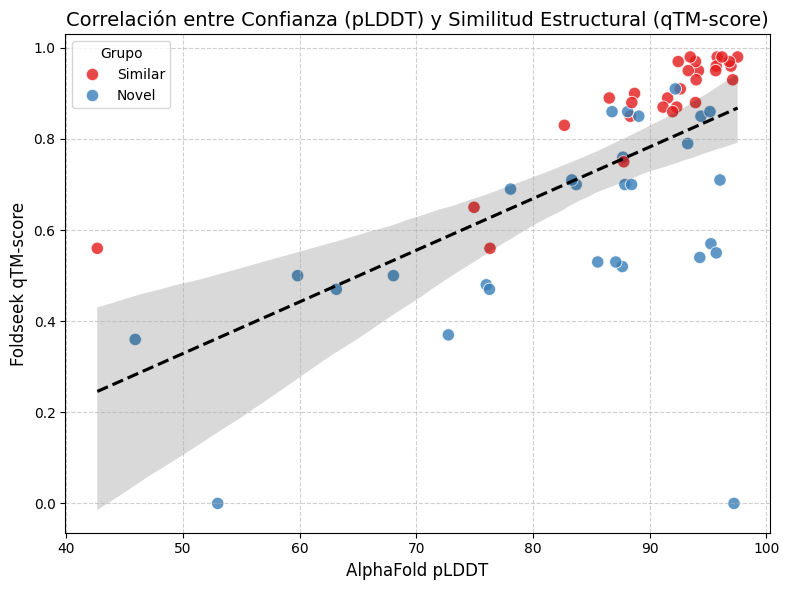

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
ruta_csv = "/content/drive/MyDrive/foldseek/Resultados_Maestros_AF2_Foldseek.csv"

# Reemplaza estos nombres con los nombres EXACTOS de las columnas en tu CSV
columna_plddt = "pLDDT_Promedio"          # <-- Cambia esto si tu columna se llama distinto
columna_tm = "Top_1_TMScore"     # <-- Columna que acabamos de corregir

# ==========================================
# 2. CARGA Y LIMPIEZA DE DATOS
# ==========================================
df = pd.read_csv(ruta_csv)

# Filtramos filas que no tengan datos numéricos en esas columnas (por si la 6KLP dejó rastros)
df_clean = df.dropna(subset=[columna_plddt, columna_tm]).copy()

# ==========================================
# 3. CÁLCULO ESTADÍSTICO
# ==========================================
# Extraemos los arreglos numéricos
x = df_clean[columna_plddt]
y = df_clean[columna_tm]

# Pearson
corr_pearson, p_pearson = pearsonr(x, y)

# Spearman
corr_spearman, p_spearman = spearmanr(x, y)

print("="*50)
print("📊 RESULTADOS DE CORRELACIÓN (pLDDT vs qTM-Score)")
print("="*50)
print(f"N (tamaño de muestra): {len(df_clean)} proteínas validas\n")

print(f"Coeficiente de Pearson: {corr_pearson:.4f}")
print(f"P-value (Pearson):      {p_pearson:.4e}")
if p_pearson < 0.05:
    print(" -> ¡La correlación de Pearson es estadísticamente significativa!\n")
else:
    print(" -> La correlación de Pearson NO es significativa.\n")

print(f"Coeficiente de Spearman: {corr_spearman:.4f}")
print(f"P-value (Spearman):      {p_spearman:.4e}")
if p_spearman < 0.05:
    print(" -> ¡La correlación de Spearman es estadísticamente significativa!\n")
else:
    print(" -> La correlación de Spearman NO es significativa.\n")
print("="*50)

# ==========================================
# 4. VISUALIZACIÓN (Opcional pero muy recomendada)
# ==========================================
plt.figure(figsize=(8, 6))

# Usamos un color distinto (hue) si tienes la columna de Clasificación
if "Clasificacion_Original" in df_clean.columns:
    sns.scatterplot(data=df_clean, x=columna_plddt, y=columna_tm,
                    hue="Clasificacion_Original", palette="Set1", s=80, alpha=0.8)
else:
    sns.scatterplot(data=df_clean, x=columna_plddt, y=columna_tm, color="blue", s=80, alpha=0.8)

# Agregar la línea de tendencia general
sns.regplot(data=df_clean, x=columna_plddt, y=columna_tm, scatter=False, color="black", line_kws={"linestyle": "--"})

plt.title('Correlación entre Confianza (pLDDT) y Similitud Estructural (qTM-score)', fontsize=14)
plt.xlabel('AlphaFold pLDDT', fontsize=12)
plt.ylabel('Foldseek qTM-score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Grupo')
plt.tight_layout()

# Mostrar la gráfica
plt.show()

📊 RESULTADOS DE CORRELACIÓN (pLDDT vs qTM-Score)
N (tamaño de muestra): 58 proteínas validas

Coeficiente de Pearson: 0.4762
P-value (Pearson):      1.5803e-04
 -> ¡La correlación de Pearson es estadísticamente significativa!

Coeficiente de Spearman: 0.4220
P-value (Spearman):      9.6881e-04
 -> ¡La correlación de Spearman es estadísticamente significativa!



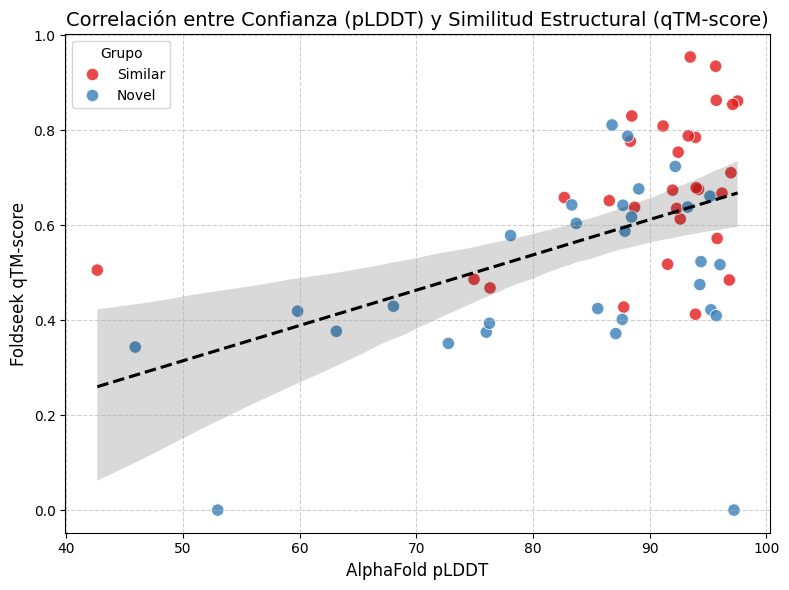

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
ruta_csv = "/content/drive/MyDrive/foldseek/Resultados_Maestros_AF2_Foldseek.csv"

# Reemplaza estos nombres con los nombres EXACTOS de las columnas en tu CSV
columna_plddt = "pLDDT_Promedio"          # <-- Cambia esto si tu columna se llama distinto
columna_tm = "Top_100_Mean"     # <-- Columna que acabamos de corregir

# ==========================================
# 2. CARGA Y LIMPIEZA DE DATOS
# ==========================================
df = pd.read_csv(ruta_csv)

# Filtramos filas que no tengan datos numéricos en esas columnas (por si la 6KLP dejó rastros)
df_clean = df.dropna(subset=[columna_plddt, columna_tm]).copy()

# ==========================================
# 3. CÁLCULO ESTADÍSTICO
# ==========================================
# Extraemos los arreglos numéricos
x = df_clean[columna_plddt]
y = df_clean[columna_tm]

# Pearson
corr_pearson, p_pearson = pearsonr(x, y)

# Spearman
corr_spearman, p_spearman = spearmanr(x, y)

print("="*50)
print("📊 RESULTADOS DE CORRELACIÓN (pLDDT vs qTM-Score)")
print("="*50)
print(f"N (tamaño de muestra): {len(df_clean)} proteínas validas\n")

print(f"Coeficiente de Pearson: {corr_pearson:.4f}")
print(f"P-value (Pearson):      {p_pearson:.4e}")
if p_pearson < 0.05:
    print(" -> ¡La correlación de Pearson es estadísticamente significativa!\n")
else:
    print(" -> La correlación de Pearson NO es significativa.\n")

print(f"Coeficiente de Spearman: {corr_spearman:.4f}")
print(f"P-value (Spearman):      {p_spearman:.4e}")
if p_spearman < 0.05:
    print(" -> ¡La correlación de Spearman es estadísticamente significativa!\n")
else:
    print(" -> La correlación de Spearman NO es significativa.\n")
print("="*50)

# ==========================================
# 4. VISUALIZACIÓN (Opcional pero muy recomendada)
# ==========================================
plt.figure(figsize=(8, 6))

# Usamos un color distinto (hue) si tienes la columna de Clasificación
if "Clasificacion_Original" in df_clean.columns:
    sns.scatterplot(data=df_clean, x=columna_plddt, y=columna_tm,
                    hue="Clasificacion_Original", palette="Set1", s=80, alpha=0.8)
else:
    sns.scatterplot(data=df_clean, x=columna_plddt, y=columna_tm, color="blue", s=80, alpha=0.8)

# Agregar la línea de tendencia general
sns.regplot(data=df_clean, x=columna_plddt, y=columna_tm, scatter=False, color="black", line_kws={"linestyle": "--"})

plt.title('Correlación entre Confianza (pLDDT) y Similitud Estructural (qTM-score)', fontsize=14)
plt.xlabel('AlphaFold pLDDT', fontsize=12)
plt.ylabel('Foldseek qTM-score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Grupo')
plt.tight_layout()

# Mostrar la gráfica
plt.show()